In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/diabetes.csv')

# Display first 5 rows
print("First 5 rows of the dataset:")
display(df.head())

# Display dataset size
print("\nDataset shape:")
print(df.shape)

# Display column names
print("\nColumn names:")
print(df.columns.tolist())

First 5 rows of the dataset:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Dataset shape:
(768, 9)

Column names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [ ]:
# Select Glucose variable
glucose = df['Glucose'].dropna()

# Display basic information
print("Selected variable: Glucose")
print("Number of observations:", len(glucose))
print("Sample mean:", glucose.mean())
print("Sample standard deviation:", glucose.std())

# Display descriptive statistics
print("\nDescriptive statistics for Glucose:")
display(glucose.describe())

Selected variable: Glucose
Number of observations: 768
Sample mean: 120.89453125
Sample standard deviation: 31.97261819513622

Descriptive statistics for Glucose:


,Glucose
count,768.000000
mean,120.894531
std,31.972618
min,0.000000
25%,99.000000
50%,117.000000
75%,140.250000
max,199.000000


In [ ]:
# Number of bootstrap samples
n_bootstrap = 10000

# Set random seed so results are reproducible
np.random.seed(42)

# Store bootstrap means
bootstrap_means = []

# Generate bootstrap samples
for i in range(n_bootstrap):

    # Randomly select observations with replacement
    bootstrap_sample = np.random.choice(
        glucose,
        size=len(glucose),
        replace=True
    )

    # Calculate the mean of the bootstrap sample
    bootstrap_mean = np.mean(bootstrap_sample)

    # Store the mean
    bootstrap_means.append(bootstrap_mean)

# Convert to NumPy array
bootstrap_means = np.array(bootstrap_means)

print("Number of bootstrap samples:", len(bootstrap_means))
print("First 10 bootstrap means:")
print(bootstrap_means[:10])

Number of bootstrap samples: 10000
First 10 bootstrap means:
[121.35286458 122.08463542 121.85677083 121.45052083 120.92708333
 119.99609375 120.1328125  120.26953125 119.65625    121.02213542]


In [ ]:
# Calculate summary statistics of bootstrap means

print("Bootstrap distribution summary")
print("--------------------------------")

print("Mean of bootstrap means:",
      np.mean(bootstrap_means))

print("Standard deviation of bootstrap means:",
      np.std(bootstrap_means))

print("Minimum bootstrap mean:",
      np.min(bootstrap_means))

print("Maximum bootstrap mean:",
      np.max(bootstrap_means))

Bootstrap distribution summary
--------------------------------
Mean of bootstrap means: 120.90175221354167
Standard deviation of bootstrap means: 1.145401595177552
Minimum bootstrap mean: 116.33463541666667
Maximum bootstrap mean: 125.265625


In [ ]:
# Calculate 95% bootstrap confidence interval

lower_ci = np.percentile(bootstrap_means, 2.5)
upper_ci = np.percentile(bootstrap_means, 97.5)

print("Original sample mean:", np.mean(glucose))

print("\n95% Bootstrap Confidence Interval")
print("-----------------------------------")
print("Lower limit:", lower_ci)
print("Upper limit:", upper_ci)

Original sample mean: 120.89453125

95% Bootstrap Confidence Interval
-----------------------------------
Lower limit: 118.69401041666667
Upper limit: 123.11588541666667


In [ ]:
# Divide data into two groups based on Outcome

non_diabetic = df[df['Outcome'] == 0]['Glucose'].dropna()
diabetic = df[df['Outcome'] == 1]['Glucose'].dropna()

# Display group sizes
print("Number of non-diabetic individuals:", len(non_diabetic))
print("Number of diabetic individuals:", len(diabetic))

# Display group means
print("\nMean Glucose Levels")
print("-------------------")
print("Non-diabetic mean:", non_diabetic.mean())
print("Diabetic mean:", diabetic.mean())

Number of non-diabetic individuals: 500
Number of diabetic individuals: 268

Mean Glucose Levels
-------------------
Non-diabetic mean: 109.98
Diabetic mean: 141.25746268656715


In [ ]:
# Calculate group means
mean_non_diabetic = non_diabetic.mean()
mean_diabetic = diabetic.mean()

# Calculate observed difference
observed_difference = mean_diabetic - mean_non_diabetic

print("Mean Glucose - Non-diabetic:", mean_non_diabetic)
print("Mean Glucose - Diabetic:", mean_diabetic)

print("\nObserved difference in means:")
print(observed_difference)

Mean Glucose - Non-diabetic: 109.98
Mean Glucose - Diabetic: 141.25746268656715

Observed difference in means:
31.277462686567148


In [ ]:
# Number of permutations
n_permutations = 10000

# Set random seed
np.random.seed(42)

# Combine all glucose observations
all_glucose = np.concatenate([non_diabetic.values, diabetic.values])

# Store permutation differences
permutation_differences = []

# Original group sizes
n_non_diabetic = len(non_diabetic)
n_diabetic = len(diabetic)

# Perform permutation test
for i in range(n_permutations):

    # Randomly shuffle the glucose values
    shuffled_glucose = np.random.permutation(all_glucose)

    # Assign the first observations to the non-diabetic group
    perm_non_diabetic = shuffled_glucose[:n_non_diabetic]

    # Assign the remaining observations to the diabetic group
    perm_diabetic = shuffled_glucose[n_non_diabetic:]

    # Calculate difference in means
    difference = (
        np.mean(perm_diabetic) -
        np.mean(perm_non_diabetic)
    )

    # Store the difference
    permutation_differences.append(difference)

# Convert to NumPy array
permutation_differences = np.array(permutation_differences)

print("Number of permutations:", len(permutation_differences))
print("First 10 permutation differences:")
print(permutation_differences[:10])

Number of permutations: 10000
First 10 permutation differences:
[ 4.01346269  0.34540299 -0.8581791   1.78970149 -1.40838806  2.75256716
 -1.2421791   2.91877612 -2.142       0.29955224]


In [ ]:
# Summary of permutation distribution

print("Permutation Distribution Summary")
print("---------------------------------")

print("Mean of permutation differences:",
      np.mean(permutation_differences))

print("Standard deviation:",
      np.std(permutation_differences))

print("Minimum difference:",
      np.min(permutation_differences))

print("Maximum difference:",
      np.max(permutation_differences))

Permutation Distribution Summary
---------------------------------
Mean of permutation differences: 0.020494853731343205
Standard deviation: 2.422618813396977
Minimum difference: -9.174358208955226
Maximum difference: 8.913761194029846


In [ ]:
# Calculate two-sided permutation p-value

p_value_permutation = np.mean(
    np.abs(permutation_differences) >= abs(observed_difference)
)

print("Observed difference:", observed_difference)
print("Permutation p-value:", p_value_permutation)

Observed difference: 31.277462686567148
Permutation p-value: 0.0


In [ ]:
# Significance level
alpha = 0.05

print("Significance level:", alpha)
print("Permutation p-value:", p_value_permutation)

if p_value_permutation < alpha:
    print("\nDecision: Reject the null hypothesis.")
    print("Conclusion: There is statistically significant evidence")
    print("of a difference in mean Glucose levels between")
    print("diabetic and non-diabetic individuals.")
else:
    print("\nDecision: Fail to reject the null hypothesis.")
    print("Conclusion: There is insufficient evidence")
    print("of a difference in mean Glucose levels between")
    print("the two groups.")

Significance level: 0.05
Permutation p-value: 0.0

Decision: Reject the null hypothesis.
Conclusion: There is statistically significant evidence
of a difference in mean Glucose levels between
diabetic and non-diabetic individuals.


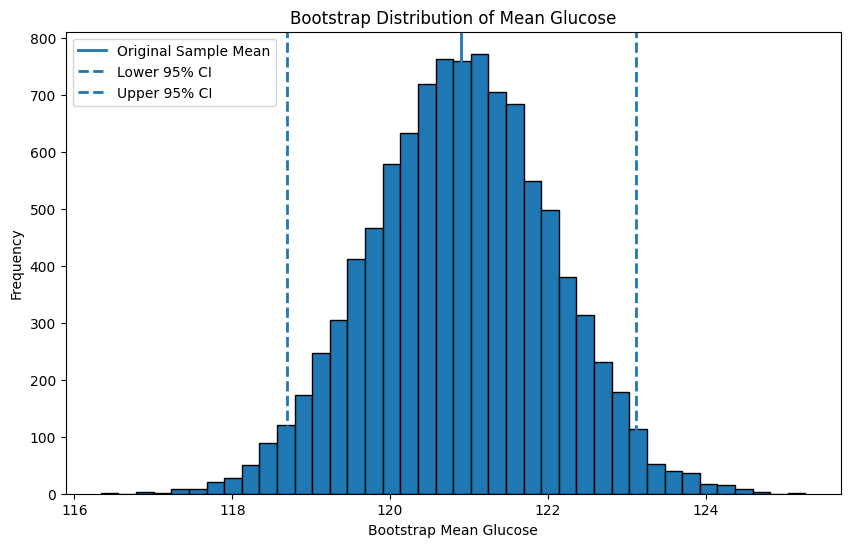

In [ ]:
# Plot bootstrap distribution

plt.figure(figsize=(10, 6))

plt.hist(
    bootstrap_means,
    bins=40,
    edgecolor='black'
)

plt.axvline(
    np.mean(glucose),
    linewidth=2,
    label='Original Sample Mean'
)

plt.axvline(
    lower_ci,
    linestyle='--',
    linewidth=2,
    label='Lower 95% CI'
)

plt.axvline(
    upper_ci,
    linestyle='--',
    linewidth=2,
    label='Upper 95% CI'
)

plt.xlabel('Bootstrap Mean Glucose')
plt.ylabel('Frequency')
plt.title('Bootstrap Distribution of Mean Glucose')
plt.legend()

plt.show()

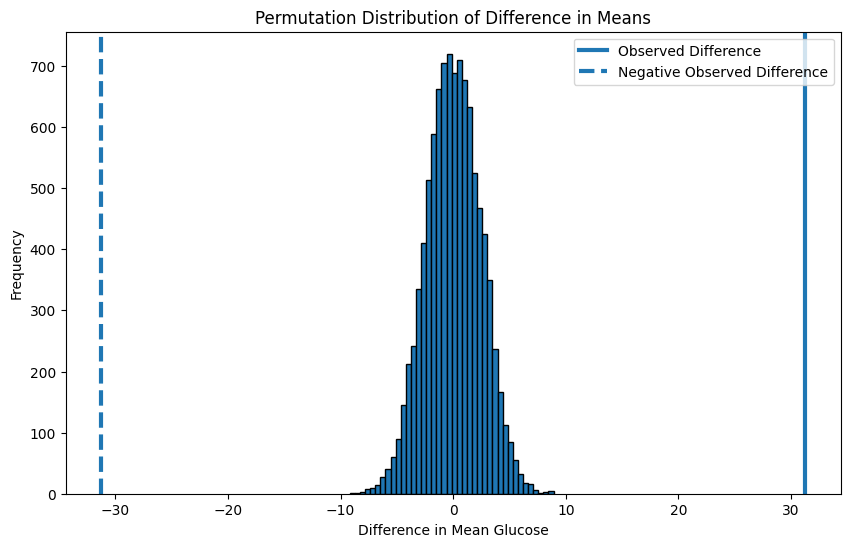

In [ ]:
# Plot permutation distribution

plt.figure(figsize=(10, 6))

plt.hist(
    permutation_differences,
    bins=40,
    edgecolor='black'
)

plt.axvline(
    observed_difference,
    linewidth=3,
    label='Observed Difference'
)

plt.axvline(
    -observed_difference,
    linewidth=3,
    linestyle='--',
    label='Negative Observed Difference'
)

plt.xlabel('Difference in Mean Glucose')
plt.ylabel('Frequency')
plt.title('Permutation Distribution of Difference in Means')
plt.legend()

plt.show()